## 1. Paths and imports


# TabPFN FP follow-up (VLST): ratio sweep + dual evaluation matrices

1. Loads **VLST** + union **`false_positives_union_test.csv`**; aligns features. **By default drops** `NO.` and `Name` (`VLST_DROP_ROW_ID_COLS` — set to `0` / `false` / `no` to keep). Those columns often yield **AUC ≈ 1** (row memorization).
2. Cohort per ratio **r**: all positives + mined FPs first + TNs until `92×r` negatives. Ratios = **1**, then **5, 10, …**, **plus `max_r = ⌊max_neg_total/92⌋`** if not already listed (so the last grid step uses ~all negatives, e.g. **44** not only **40**), then optional **full_pool** if it differs.
3. **Stratified 60/20/20** → **TabPFN** fits **train 60%** only. **split_a** = cohort **holdout** (20%, has positives). **split_b** = full eval pool minus rows in the **fit** fold.
4. **Thresholds** (printed + CSV): **0.5** · **val→F0.5/F1/F2** · **hold→F0.5/F1/F2*** (holdout oracle).
5. **§5** curves (F-score, FP/FN, ROC/PR-AUC): validation, split_a holdout, split_b@val-t, split_b oracle (see §5 table).
6. **`fp_followup_ratio_sweep.csv`**, §4 scrollable table when IPython is available.

**Backend:** `tabpfn-client` (cloud).

**Env:** `VLST_FULL_DATA_PATH`, `VLST_FP_OUTPUT_DIR`, `TABPFN_TOKEN`, `VLST_TABPFN_FOLLOWUP_SEED`, `VLST_DROP_ROW_ID_COLS`, `TABPFN_N_ESTIMATORS`.



In [1]:
import os
import warnings

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = int(os.environ.get("VLST_TABPFN_FOLLOWUP_SEED", "42"))

FULL_DATA_PATH = os.environ.get(
    "VLST_FULL_DATA_PATH",
    "/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv",
)


def pick_output_dir_modeling_fp() -> str:
    out = os.environ.get("VLST_FP_FOLLOWUP_OUT_DIR")
    if out:
        return os.path.expanduser(out.rstrip(os.sep))
    if os.path.isdir("/kaggle/working"):
        return "/kaggle/working/vlst_fp_followup_output"
    return os.path.normpath(os.path.join("..", "..", "data", "result", "modeling_fp"))


OUTPUT_DIR = pick_output_dir_modeling_fp()
os.makedirs(OUTPUT_DIR, exist_ok=True)


def pick_fp_mining_output_dir() -> str:
    out = os.environ.get("VLST_FP_OUTPUT_DIR") or os.environ.get("VLST_FP_MINING_OUT")
    if not out:
        kaggle_fp_out = "/kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output"
        if os.path.isdir(kaggle_fp_out):
            out = kaggle_fp_out
    if out:
        out = os.path.expanduser(out.rstrip(os.sep))
    elif os.path.isdir("/kaggle/working"):
        out = "/kaggle/working/vlst_fp_mining_output"
    else:
        repo_modeling_fp = os.path.normpath(
            os.path.join("..", "..", "data", "result", "modeling_fp")
        )
        if os.path.isfile(os.path.join(repo_modeling_fp, "false_positives_union_test.csv")):
            out = repo_modeling_fp
        else:
            out = os.path.normpath(
                os.path.join("..", "..", "data", "result", "modeling_advanced", "fp_mining")
            )
    tag = os.environ.get("VLST_FP_RUN_TAG", "").strip()
    if tag:
        out = os.path.join(out, tag)
    return out


FP_MINING_OUT = pick_fp_mining_output_dir()
UNION_CSV = os.path.join(FP_MINING_OUT, "false_positives_union_test.csv")

print("FULL_DATA_PATH:", FULL_DATA_PATH)
print("Follow-up artifacts dir (OUTPUT_DIR):", OUTPUT_DIR)
print("FP mining outputs (union CSV):", FP_MINING_OUT)
print("Union CSV:", UNION_CSV)


FULL_DATA_PATH: /kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv
Follow-up artifacts dir (OUTPUT_DIR): /kaggle/working/vlst_fp_followup_output
FP mining outputs (union CSV): /kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output
Union CSV: /kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output/false_positives_union_test.csv


In [2]:
!pip install -U tabpfn-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 699.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.8/240.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests=

In [3]:
from tabpfn_client import set_access_token

_token = os.environ.get("TABPFN_TOKEN", "").strip()
if not _token:
    try:
        from kaggle_secrets import UserSecretsClient

        _token = str(UserSecretsClient().get_secret("TABPFN_TOKEN")).strip()
        os.environ["TABPFN_TOKEN"] = _token
    except Exception:
        pass

if _token:
    set_access_token(_token)
    print("TabPFN client: access token configured (value hidden).")
else:
    print(
        "Set TABPFN_TOKEN (Kaggle Secret, shell export, or os.environ) before §3. "
        "Get a key at https://ux.priorlabs.ai/account"
    )


TabPFN client: access token configured (value hidden).


## 2. Load data, align features, train/test pools, ratio schedule


In [4]:
if not os.path.isfile(FULL_DATA_PATH):
    raise FileNotFoundError(
        f"Missing full dataset at {FULL_DATA_PATH}. Set VLST_FULL_DATA_PATH before running."
    )
if not os.path.isfile(UNION_CSV):
    raise FileNotFoundError(
        f"Missing {UNION_CSV}. Run fp mining export first or set VLST_FP_OUTPUT_DIR / VLST_FP_RUN_TAG."
    )

df_full = pd.read_csv(FULL_DATA_PATH, low_memory=False)
df_union = pd.read_csv(UNION_CSV, low_memory=False)
if "test_row_id" not in df_union.columns:
    raise ValueError("Union CSV must contain test_row_id.")


def _norm_col(s: str) -> str:
    return "".join(ch.lower() for ch in str(s).strip() if ch.isalnum())


col_map = {_norm_col(c): c for c in df_full.columns}

forced_target = os.environ.get("VLST_FULLDATA_TARGET_COL", "").strip()
if forced_target:
    fk = _norm_col(forced_target)
    if fk not in col_map:
        raise ValueError(
            f"VLST_FULLDATA_TARGET_COL={forced_target!r} not found. "
            f"Available columns include: {list(df_full.columns)[:12]} ..."
        )
    target_col = col_map[fk]
else:
    preferred = [
        "Stent thrombosis",
        "stent_thrombosis",
        "StentThrombosis",
        "target",
        "label",
        "y",
        "class",
        "Outcome",
        "VLST",
    ]
    target_col = None
    for c in preferred:
        k = _norm_col(c)
        if k in col_map:
            cand = col_map[k]
            vals = set(
                pd.to_numeric(df_full[cand], errors="coerce")
                .dropna()
                .astype(int)
                .unique()
                .tolist()
            )
            if vals.issubset({0, 1}) and len(vals) >= 1:
                target_col = cand
                break
    if target_col is None:
        raise ValueError(
            "Could not confidently infer target column. "
            "Set VLST_FULLDATA_TARGET_COL='Stent thrombosis' (or your label column name)."
        )

print("Using target column from full data:", target_col)

y_full = pd.to_numeric(df_full[target_col], errors="coerce").fillna(0).astype(int).to_numpy()
if not set(np.unique(y_full)).issubset({0, 1}):
    raise ValueError("Target column must be binary (0/1).")

X_full_df = df_full.drop(columns=[target_col]).copy()

_drop_ids = os.environ.get("VLST_DROP_ROW_ID_COLS", "1").strip().lower() not in (
    "0",
    "false",
    "no",
)
if _drop_ids:
    _id_cols = [c for c in ("NO.", "Name") if c in X_full_df.columns]
    if _id_cols:
        X_full_df = X_full_df.drop(columns=_id_cols)
        print("Dropped row-identifier columns from features:", _id_cols)


def _norm_name(s: str) -> str:
    return "".join(ch.lower() for ch in str(s) if ch.isalnum())


_drop_norm = {
    _norm_name("Time since stent implantation"),
    _norm_name("time_since_implantation"),
    _norm_name("time since implantation"),
}
_drop_cols = [c for c in X_full_df.columns if _norm_name(c) in _drop_norm]
if _drop_cols:
    X_full_df = X_full_df.drop(columns=_drop_cols)
    print("Dropped leakage-style feature(s):", _drop_cols)

for c in X_full_df.columns:
    X_full_df[c] = pd.to_numeric(X_full_df[c], errors="coerce")

meta_cols = {
    "test_row_id",
    "y_true",
    "p_winner",
    "p_tabpfn",
    "fp_winner",
    "fp_tabpfn_legacy_t",
    "fp_tabpfn_any_grid_t",
    "source",
    "threshold",
}
shared_features = [c for c in X_full_df.columns if c not in meta_cols]
if not shared_features:
    raise ValueError("No feature columns in full dataset after exclusions.")

_union_feat = [c for c in df_union.columns if c not in meta_cols]
union_only_cols = [c for c in _union_feat if c not in X_full_df.columns]
if union_only_cols:
    print(
        "Note: union CSV has",
        len(union_only_cols),
        "feature column(s) not in full data (omitted from training schema); examples:",
        union_only_cols[:12],
    )

X_full_use = X_full_df[shared_features].copy()
X_union_use = df_union.reindex(columns=shared_features)
for c in shared_features:
    X_union_use[c] = pd.to_numeric(X_union_use[c], errors="coerce")

med = X_full_use.median(numeric_only=True)
X_full_use = X_full_use.fillna(med)
X_union_use = X_union_use.fillna(med)

_union_ids = pd.to_numeric(df_union["test_row_id"], errors="coerce")
_rid = np.where(np.isfinite(_union_ids.to_numpy(dtype=float)), _union_ids.to_numpy(dtype=float), -1.0).astype(np.int64)
_valid_overlay = (_rid >= 0) & (_rid < len(X_full_df))
if int(_valid_overlay.sum()) > 0:
    _vi = np.flatnonzero(_valid_overlay)
    X_union_use.iloc[_vi, :] = X_full_use.iloc[_rid[_vi]].to_numpy(dtype=np.float32, copy=False)
    print(
        "Union FP rows overlaid from full VLST by test_row_id:",
        int(_valid_overlay.sum()),
        "/",
        len(df_union),
    )
else:
    print(
        "Warning: no union test_row_id in [0, n_rows(VLST)); FP rows stay union CSV + median only."
    )

assert (
    X_full_use.shape[1] == len(shared_features) == X_union_use.shape[1]
), (X_full_use.shape[1], len(shared_features), X_union_use.shape[1])

rng = np.random.RandomState(RANDOM_STATE)
pos_idx = np.flatnonzero(y_full == 1)
tn_pool_idx = np.flatnonzero(y_full == 0)
if pos_idx.size == 0:
    raise ValueError("No positives in full dataset.")

union_full_row_ids = set(int(x) for x in df_union["test_row_id"].astype(int).tolist())

# Eligible true negatives for TN fill / test reserve: label 0 and not a union row id
tn_elig = np.array(
    sorted(i for i in tn_pool_idx.tolist() if int(i) not in union_full_row_ids),
    dtype=int,
)
if tn_elig.size < 32:
    tn_elig = np.array(sorted(tn_pool_idx.tolist()), dtype=int)

# Reserve a slice of eligible TNs for the "left-out" pool (never in cohort TN fill)
TEST_NEG_FRAC = float(os.environ.get("VLST_FP_FOLLOWUP_TEST_NEG_FRAC", "0.2"))
if not (0.0 < TEST_NEG_FRAC < 0.5):
    raise ValueError("VLST_FP_FOLLOWUP_TEST_NEG_FRAC must be in (0, 0.5).")
ix_tn = np.arange(len(tn_elig), dtype=int)
tn_train_ix, tn_test_ix = train_test_split(
    ix_tn,
    test_size=TEST_NEG_FRAC,
    random_state=RANDOM_STATE,
    shuffle=True,
)
TestFixed_neg = tn_elig[tn_test_ix]  # extra negatives for split_b only
tn_for_train_pool = tn_elig[tn_train_ix]

# Deterministic shuffle order for consuming extra negatives across ratio steps
perm_tn = rng.permutation(len(tn_for_train_pool))
tn_ordered = tn_for_train_pool[perm_tn]

fp_mat_all = X_union_use.to_numpy(dtype=np.float32)
n_fp = int(fp_mat_all.shape[0])
n_pos = int(pos_idx.size)

X_pos_all = X_full_use.iloc[pos_idx].to_numpy(dtype=np.float32)
y_pos_vec = np.ones(n_pos, dtype=int)

max_neg_total = n_fp + int(tn_ordered.size)
max_r = int(max_neg_total // n_pos) if n_pos else 0
ratio_candidates = [1] + list(range(5, max(max_r, 5) + 1, 5))
if max_r >= 1 and max_r not in ratio_candidates:
    ratio_candidates.append(max_r)
ratio_candidates = sorted(set(int(x) for x in ratio_candidates))
RATIOS = []
for r in ratio_candidates:
    need = n_pos * int(r)
    if need <= max_neg_total:
        RATIOS.append(int(r))

if not RATIOS:
    raise RuntimeError("No valid ratio steps (check TN pool and n_fp).")

# Full-pool negative count (all FPs + all train-pool TNs)
n_neg_full = n_fp + int(tn_ordered.size)

split_summary = {
    "n_pos": n_pos,
    "n_fp_union": n_fp,
    "n_tn_train_pool": int(tn_ordered.size),
    "n_TestFixed_neg": int(TestFixed_neg.size),
    "max_neg_total": max_neg_total,
    "max_r_neg_ratio": int(max_r),
    "ratios": RATIOS,
    "n_neg_full_pool": int(n_neg_full),
    "TEST_NEG_FRAC": TEST_NEG_FRAC,
}
print("Split / ratio summary:", split_summary)
print("Features (shared_features):", len(shared_features))


def stratified_602020(X_mat: np.ndarray, y_vec: np.ndarray, random_state: int):
    """60/20/20 stratified split; returns folds and index arrays."""
    idx = np.arange(len(y_vec), dtype=int)
    i_tr, i_temp = train_test_split(
        idx,
        test_size=0.4,
        random_state=random_state,
        shuffle=True,
        stratify=y_vec,
    )
    i_va, i_ho = train_test_split(
        i_temp,
        test_size=0.5,
        random_state=random_state,
        shuffle=True,
        stratify=y_vec[i_temp],
    )
    return (
        X_mat[i_tr],
        y_vec[i_tr],
        X_mat[i_va],
        y_vec[i_va],
        X_mat[i_ho],
        y_vec[i_ho],
        i_tr,
        i_va,
        i_ho,
    )


def build_train_arrays(n_neg_target: int, rng_step: np.random.RandomState):
    """Cohort: all positives + mined FPs first + TN fill. Returns full-table row id per row."""
    need = int(min(n_neg_target, n_fp + tn_ordered.size))
    n_fp_take = min(n_fp, need)
    need_after_fp = need - n_fp_take
    X_fp_part = fp_mat_all[:n_fp_take] if n_fp_take > 0 else np.empty((0, fp_mat_all.shape[1]), dtype=np.float32)
    tn_take = int(min(need_after_fp, tn_ordered.size))
    if tn_take > 0:
        tn_idx_used = tn_ordered[:tn_take]
        X_tn_part = X_full_use.iloc[tn_idx_used].to_numpy(dtype=np.float32)
    else:
        tn_idx_used = np.array([], dtype=int)
        X_tn_part = np.empty((0, fp_mat_all.shape[1]), dtype=np.float32)

    full_ix_list = (
        [int(i) for i in pos_idx.tolist()]
        + [int(df_union.iloc[j]["test_row_id"]) for j in range(n_fp_take)]
        + [int(i) for i in tn_idx_used.tolist()]
    )
    X_all = np.vstack([X_pos_all, X_fp_part, X_tn_part]).astype(np.float32)
    y_all = np.concatenate(
        [
            y_pos_vec,
            np.zeros(n_fp_take, dtype=int),
            np.zeros(tn_take, dtype=int),
        ]
    )
    full_ix = np.asarray(full_ix_list, dtype=np.int64)
    perm = rng_step.permutation(len(y_all))
    X_all, y_all, full_ix = X_all[perm], y_all[perm], full_ix[perm]
    return X_all, y_all, full_ix, n_fp_take, tn_idx_used


def pool_full_idx_set():
    return (
        set(int(x) for x in pos_idx.tolist())
        | set(int(x) for x in tn_elig.tolist())
        | set(int(x) for x in union_full_row_ids)
    )


def Xy_for_full_indices(indices: np.ndarray):
    # Features/labels for full-table row indices.
    indices = np.asarray(indices, dtype=int)
    Xb = X_full_use.iloc[indices].to_numpy(dtype=np.float32)
    yb = y_full[indices].astype(int)
    return Xb, yb


def matrix_b_indices(train_fit_full_idx: set):
    """Full-table rows in eval pool but not in TabPFN .fit() train fold."""
    pool = pool_full_idx_set()
    return np.asarray(sorted(pool - set(train_fit_full_idx)), dtype=int)





Using target column from full data: Stent thrombosis
Dropped row-identifier columns from features: ['NO.', 'Name']
Dropped leakage-style feature(s): ['Time since stent implantation']
Note: union CSV has 93 feature column(s) not in full data (omitted from training schema); examples: ['Stent type-SES_Endeavor', 'Stent type-SES_Ex', 'Stent type-SES_Ex/Pa', 'Stent type-SES_Excecl', 'Stent type-SES_Excel', 'Stent type-SES_Excel/Firebird', 'Stent type-SES_Excel/Partner', 'Stent type-SES_Excel:RCA', 'Stent type-SES_Firebid', 'Stent type-SES_Firebird', 'Stent type-SES_LAD:Excel', 'Stent type-SES_LAD:Firebird']
Union FP rows overlaid from full VLST by test_row_id: 44 / 44
Split / ratio summary: {'n_pos': 92, 'n_fp_union': 44, 'n_tn_train_pool': 4039, 'n_TestFixed_neg': 1010, 'max_neg_total': 4083, 'max_r_neg_ratio': 44, 'ratios': [1, 5, 10, 15, 20, 25, 30, 35, 40, 44], 'n_neg_full_pool': 4083, 'TEST_NEG_FRAC': 0.2}
Features (shared_features): 81


## 3. Ratio sweep — TabPFN, F0.5 threshold, dual confusion matrices + CSV


In [5]:
from tabpfn_client import TabPFNClassifier, set_access_token

_token = os.environ.get("TABPFN_TOKEN", "").strip()
if not _token:
    raise RuntimeError(
        "TABPFN_TOKEN missing. Run the token cell above (Kaggle Secret or env var). "
        "API key: https://ux.priorlabs.ai/account"
    )
set_access_token(_token)

TABPFN_N_ESTIMATORS = int(os.environ.get("TABPFN_N_ESTIMATORS", "8"))


def make_tabpfn_classifier(random_state: int) -> TabPFNClassifier:
    """tabpfn-client API (cloud); no local `device` argument."""
    return TabPFNClassifier(
        random_state=random_state,
        n_estimators=TABPFN_N_ESTIMATORS,
        ignore_pretraining_limits=True,
        balance_probabilities=True,
    )

t_grid = np.arange(0.01, 1.0, 0.01)


def best_threshold(y_true, p, grid, metric_fn):
    best_t, best_v = 0.5, -1.0
    for t in grid:
        y_hat = (p >= t).astype(int)
        v = float(metric_fn(y_true, y_hat))
        if v > best_v:
            best_v, best_t = v, float(t)
    return best_t, best_v


def f05m(y, yhat):
    return fbeta_score(y, yhat, beta=0.5, zero_division=0)


def f1m(y, yhat):
    return f1_score(y, yhat, zero_division=0)


def f2m(y, yhat):
    return fbeta_score(y, yhat, beta=2.0, zero_division=0)


def tune_thresholds(y_true, p, grid):
    """Best cutoff on `grid` for F0.5, F1, and F2."""
    t_f05, v_f05 = best_threshold(y_true, p, grid, f05m)
    t_f1, v_f1 = best_threshold(y_true, p, grid, f1m)
    t_f2, v_f2 = best_threshold(y_true, p, grid, f2m)
    return {
        "t_f05": float(t_f05),
        "v_f05": float(v_f05),
        "t_f1": float(t_f1),
        "v_f1": float(v_f1),
        "t_f2": float(t_f2),
        "v_f2": float(v_f2),
    }


def tune_val_thresholds(y_va, p_va):
    return tune_thresholds(y_va, p_va, t_grid)


def tune_hold_thresholds(y_ho, p_ho):
    return tune_thresholds(y_ho, p_ho, t_grid)


def f_scores_at_t(y, p, t):
    yh = (p >= float(t)).astype(int)
    return float(f05m(y, yh)), float(f1m(y, yh)), float(f2m(y, yh))


def metric_bundle(y_true, y_hat, p):
    out = {
        "precision": float(precision_score(y_true, y_hat, zero_division=0)),
        "recall": float(recall_score(y_true, y_hat, zero_division=0)),
        "f1": float(f1_score(y_true, y_hat, zero_division=0)),
        "f05": float(fbeta_score(y_true, y_hat, beta=0.5, zero_division=0)),
        "f2": float(fbeta_score(y_true, y_hat, beta=2.0, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_hat)),
    }
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, p))
    except ValueError:
        out["roc_auc"] = float("nan")
    try:
        out["pr_auc"] = float(average_precision_score(y_true, p))
    except ValueError:
        out["pr_auc"] = float("nan")
    return out


def print_confusion_compact(cm):
    cm = np.asarray(cm, dtype=int)
    if cm.shape == (2, 2):
        print(
            f"      TN={cm[0, 0]:>6}  FP={cm[0, 1]:>6}  |  "
            f"FN={cm[1, 0]:>6}  TP={cm[1, 1]:>6}"
        )
    else:
        print("     ", cm.tolist())


def append_eval_row(d, prefix, y_true, p, t_use, label):
    y_hat = (p >= float(t_use)).astype(int)
    mb = metric_bundle(y_true, y_hat, p)
    for k, v in mb.items():
        d[f"{prefix}_{label}_{k}"] = float(v)
    cm = confusion_matrix(y_true, y_hat, labels=[0, 1])
    d[f"{prefix}_{label}_cm00"] = int(cm[0, 0])
    d[f"{prefix}_{label}_cm01"] = int(cm[0, 1])
    d[f"{prefix}_{label}_cm10"] = int(cm[1, 0])
    d[f"{prefix}_{label}_cm11"] = int(cm[1, 1])


def append_fp_fn_cols(d, prefix, y_true, p, t_use, label):
    """Store FP (cm01) and FN (cm10) only — for error-count curves."""
    y_hat = (p >= float(t_use)).astype(int)
    cm = confusion_matrix(y_true, y_hat, labels=[0, 1])
    d[f"{prefix}_{label}_fp"] = int(cm[0, 1])
    d[f"{prefix}_{label}_fn"] = int(cm[1, 0])


def print_split_eval(split_label, y, p, cutoffs):
    """One eval split: compact metrics + confusion matrix per cutoff."""
    mb_auc = metric_bundle(y, (p >= 0.5).astype(int), p)
    print(
        f"\n  {split_label}  |  n={len(y)}  pos={int(y.sum())}  "
        f"|  ROC-AUC {mb_auc['roc_auc']:.3f}  PR-AUC {mb_auc['pr_auc']:.3f}"
    )
    for tag, t in cutoffs:
        yh = (p >= float(t)).astype(int)
        mb = metric_bundle(y, yh, p)
        print(
            f"    {tag:<14}  t={float(t):.3f}  "
            f"P={mb['precision']:.3f}  R={mb['recall']:.3f}  "
            f"F0.5={mb['f05']:.3f}  F1={mb['f1']:.3f}  F2={mb['f2']:.3f}  acc={mb['accuracy']:.3f}"
        )
        print_confusion_compact(confusion_matrix(y, yh, labels=[0, 1]))


def append_split_csv_rows(row, prefix, y, p, val_t, hold_t):
    append_eval_row(row, prefix, y, p, 0.5, "t05")
    append_eval_row(row, prefix, y, p, val_t["t_f05"], "tval")
    append_eval_row(row, prefix, y, p, val_t["t_f1"], "tval_f1")
    append_eval_row(row, prefix, y, p, val_t["t_f2"], "tval_f2")
    append_eval_row(row, prefix, y, p, hold_t["t_f05"], "thold")
    append_eval_row(row, prefix, y, p, hold_t["t_f1"], "thold_f1")
    append_eval_row(row, prefix, y, p, hold_t["t_f2"], "thold_f2")


def print_ratio_eval(step_label, y_a, p_a, y_b, p_b, val_t, hold_t):
    cutoffs = [
        ("fixed 0.5", 0.5),
        ("val | F0.5", val_t["t_f05"]),
        ("val | F1", val_t["t_f1"]),
        ("val | F2", val_t["t_f2"]),
        ("hold|F0.5*", hold_t["t_f05"]),
        ("hold|F1*", hold_t["t_f1"]),
        ("hold|F2*", hold_t["t_f2"]),
    ]
    print(f"\n{'=' * 72}")
    print(
        f"{step_label}  |  val t:  F0.5={val_t['t_f05']:.3f}  F1={val_t['t_f1']:.3f}  F2={val_t['t_f2']:.3f}"
    )
    print(
        f"  holdout* t:  F0.5={hold_t['t_f05']:.3f}  F1={hold_t['t_f1']:.3f}  F2={hold_t['t_f2']:.3f}"
    )
    print_split_eval("split_a  holdout", y_a, p_a, cutoffs)
    print_split_eval("split_b  pool \\ fit", y_b, p_b, cutoffs)


def threshold_curve_meta(
    val_t, hold_a_t, hold_b_t, y_va, p_va, y_ho, p_ho, y_b, p_b,
    n_neg_target, n_fp_take, tn_used, X_tr, X_va,
):
    vf05, vf1, vf2 = f_scores_at_t(y_va, p_va, 0.5)
    hf05, hf1, hf2 = f_scores_at_t(y_ho, p_ho, 0.5)
    bf05, bf1, bf2 = f_scores_at_t(y_b, p_b, 0.5)
    mb_va = metric_bundle(y_va, (p_va >= 0.5).astype(int), p_va)
    mb_ho = metric_bundle(y_ho, (p_ho >= 0.5).astype(int), p_ho)
    mb_b = metric_bundle(y_b, (p_b >= 0.5).astype(int), p_b)
    return {
        "n_neg_target": int(n_neg_target),
        "n_fp_in_constructed": int(n_fp_take),
        "n_tn_in_constructed": int(len(tn_used)),
        "n_fit_train": int(X_tr.shape[0]),
        "n_fit_val": int(X_va.shape[0]),
        "t_val_best_f05": val_t["t_f05"],
        "val_roc_auc": mb_va["roc_auc"],
        "val_pr_auc": mb_va["pr_auc"],
        "hold_a_roc_auc": mb_ho["roc_auc"],
        "hold_a_pr_auc": mb_ho["pr_auc"],
        "split_b_roc_auc": mb_b["roc_auc"],
        "split_b_pr_auc": mb_b["pr_auc"],
        "val_f05_at_t_val": val_t["v_f05"],
        "t_val_best_f1": val_t["t_f1"],
        "val_f1_at_t_val_f1": val_t["v_f1"],
        "t_val_best_f2": val_t["t_f2"],
        "val_f2_at_t_val_f2": val_t["v_f2"],
        "val_f05_at_t05": vf05,
        "val_f1_at_t05": vf1,
        "val_f2_at_t05": vf2,
        "t_hold_oracle_best_f05": hold_a_t["t_f05"],
        "hold_f05_at_t_hold": hold_a_t["v_f05"],
        "t_hold_oracle_best_f1": hold_a_t["t_f1"],
        "hold_f1_at_t_hold_f1": hold_a_t["v_f1"],
        "t_hold_oracle_best_f2": hold_a_t["t_f2"],
        "hold_f2_at_t_hold_f2": hold_a_t["v_f2"],
        "hold_f05_at_t05": hf05,
        "hold_f1_at_t05": hf1,
        "hold_f2_at_t05": hf2,
        "t_hold_b_oracle_best_f05": hold_b_t["t_f05"],
        "b_hold_f05_at_oracle": hold_b_t["v_f05"],
        "t_hold_b_oracle_best_f1": hold_b_t["t_f1"],
        "b_hold_f1_at_oracle": hold_b_t["v_f1"],
        "t_hold_b_oracle_best_f2": hold_b_t["t_f2"],
        "b_hold_f2_at_oracle": hold_b_t["v_f2"],
        "b_hold_f05_at_t05": bf05,
        "b_hold_f1_at_t05": bf1,
        "b_hold_f2_at_t05": bf2,
        "split_a_n": int(len(y_ho)),
        "split_a_pos": int(y_ho.sum()),
        "split_b_n": int(len(y_b)),
        "split_b_pos": int(y_b.sum()),
    }


def run_one_sweep_step(step_label, step_kind, ratio_requested, n_neg_target, rs_seed, split_seed):
    rs = np.random.RandomState(rs_seed)
    X_all, y_all, full_ix, n_fp_take, tn_used = build_train_arrays(n_neg_target, rs)
    X_tr, y_tr, X_va, y_va, X_ho, y_ho, i_tr, _, _ = stratified_602020(X_all, y_all, split_seed)
    train_fit_ix = set(int(x) for x in full_ix[i_tr].tolist())

    clf = make_tabpfn_classifier(split_seed)
    clf.fit(X_tr, y_tr)
    p_va = clf.predict_proba(X_va)[:, 1]
    val_t = tune_val_thresholds(y_va, p_va)

    p_a = clf.predict_proba(X_ho)[:, 1]
    hold_a_t = tune_hold_thresholds(y_ho, p_a)

    b_ix = matrix_b_indices(train_fit_ix)
    X_b, y_b = Xy_for_full_indices(b_ix)
    p_b = clf.predict_proba(X_b)[:, 1]
    hold_b_t = tune_hold_thresholds(y_b, p_b)

    print_ratio_eval(step_label, y_ho, p_a, y_b, p_b, val_t, hold_a_t)

    row = {
        "step_kind": step_kind,
        "ratio_requested": int(ratio_requested),
        **threshold_curve_meta(
            val_t,
            hold_a_t,
            hold_b_t,
            y_va,
            p_va,
            y_ho,
            p_a,
            y_b,
            p_b,
            n_neg_target,
            n_fp_take,
            tn_used,
            X_tr,
            X_va,
        ),
    }
    append_fp_fn_cols(row, "val", y_va, p_va, 0.5, "t05")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_f05"], "tval")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_f1"], "tval_f1")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_f2"], "tval_f2")
    for prefix, yv, pv in (("a", y_ho, p_a), ("b", y_b, p_b)):
        append_split_csv_rows(row, prefix, yv, pv, val_t, hold_a_t)
    append_eval_row(row, "b", y_b, p_b, hold_b_t["t_f05"], "thold_b")
    append_eval_row(row, "b", y_b, p_b, hold_b_t["t_f1"], "thold_b_f1")
    append_eval_row(row, "b", y_b, p_b, hold_b_t["t_f2"], "thold_b_f2")
    return row


print("Thresholds: 0.5 | val→F0.5/F1/F2 | hold→F0.5/F1/F2* (oracle)")
sweep_rows = []
step_i = 0

for r in RATIOS:
    n_neg_target = n_pos * int(r)
    sweep_rows.append(
        run_one_sweep_step(
            f"ratio={r}",
            "ratio",
            r,
            n_neg_target,
            RANDOM_STATE + step_i * 9973,
            RANDOM_STATE + step_i,
        )
    )
    step_i += 1

rs = np.random.RandomState(RANDOM_STATE + step_i * 9973)
X_all_f, y_all_f, full_ix_f, n_fp_f, tn_used_f = build_train_arrays(n_neg_full, rs)
last_same = False
if sweep_rows:
    last = sweep_rows[-1]
    last_same = (
        int(last["n_fp_in_constructed"]) == int(n_fp_f)
        and int(last["n_tn_in_constructed"]) == int(len(tn_used_f))
    )
if not last_same:
    sweep_rows.append(
        run_one_sweep_step(
            "full_pool",
            "full_pool",
            -1,
            n_neg_full,
            RANDOM_STATE + step_i * 9973,
            RANDOM_STATE + step_i,
        )
    )
else:
    print("Full-pool step skipped (identical to last ratio iteration).")

sweep_df = pd.DataFrame(sweep_rows)
_sweep_path = os.path.join(OUTPUT_DIR, "fp_followup_ratio_sweep.csv")
sweep_df.to_csv(_sweep_path, index=False)
print("\nTabPFN backend: tabpfn-client (cloud API)")
print("Saved:", _sweep_path, "rows:", len(sweep_df))



Thresholds: 0.5 | val→F0.5/F1/F2 | hold→F0.5/F1/F2* (oracle)
00:00 Fitting... |

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
00:00 Predicting... \

...

00:01 Predicting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:02 Predicting... Done!

full_pool  |  val t:  F0.5=0.930  F1=0.880  F2=0.780
  holdout* t:  F0.5=0.960  F1=0.900  F2=0.870

  split_a  holdout  |  n=835  pos=19  |  ROC-AUC 0.986  PR-AUC 0.631
    fixed 0.5       t=0.500  P=0.183  R=1.000  F0.5=0.218  F1=0.309  F2=0.528  acc=0.898
      TN=   731  FP=    85  |  FN=     0  TP=    19
    val | F0.5      t=0.930  P=0.611  R=0.579  F0.5=0.604  F1=0.595  F2=0.585  acc=0.982
      TN=   809  FP=     7  |  FN=     8  TP=    11
    val | F1        t=0.880  P=0.500  R=0.789  F0.5=0.540  F1=0.612  F2=0.708  acc=0.977
      TN=   801  FP=    15  |  FN=     4  TP=    15
    val | F2        t=0.780  P=0.305  R=0.947  F0.5=0.353  F1=0.462  F2=0.667  acc=0.950
      TN=   775  FP=    41  |  FN=     1  TP=    18
    hold|F0.5*      t=0.960  P=0.750  R=0.474  F0.5=0.672  F1=0.581  F2=0.511  acc=0.984
      TN=   813  FP=     3  |  FN=    10  TP=     9
    hold|F1*        t=0.900  P=0.536  R=0.789  F0.5=0.573  F1=0.638  F2=0.721  acc=0.980
      TN= 

## 4. Output


In [6]:
_p = os.path.join(OUTPUT_DIR, "fp_followup_ratio_sweep.csv")
print("Primary sweep table:", _p)
if len(sweep_df):
    try:
        from IPython.display import HTML, display

        _html = sweep_df.to_html(
            classes="followup_tbl", escape=False, float_format=lambda x: f"{x:.6g}"
        )
        display(
            HTML(
                "<style>.followup_tbl{font-size:11px;} "
                ".followup_tbl th,.followup_tbl td{white-space:nowrap;padding:4px 8px;}</style>"
                '<div style="max-height:480px;overflow:auto;border:1px solid #ccc;padding:8px;">'
                + _html
                + "</div>"
            )
        )
    except Exception:
        print(sweep_df.to_string())



Primary sweep table: /kaggle/working/vlst_fp_followup_output/fp_followup_ratio_sweep.csv


,step_kind,ratio_requested,n_neg_target,n_fp_in_constructed,n_tn_in_constructed,n_fit_train,n_fit_val,t_val_best_f05,val_f05_at_t_val,t_val_best_f1,val_f1_at_t_val_f1,t_val_best_f2,val_f2_at_t_val_f2,val_f05_at_t05,val_f1_at_t05,val_f2_at_t05,t_hold_oracle_best_f05,hold_f05_at_t_hold,t_hold_oracle_best_f1,hold_f1_at_t_hold_f1,t_hold_oracle_best_f2,hold_f2_at_t_hold_f2,hold_f05_at_t05,hold_f1_at_t05,hold_f2_at_t05,t_hold_b_oracle_best_f05,b_hold_f05_at_oracle,t_hold_b_oracle_best_f1,b_hold_f1_at_oracle,t_hold_b_oracle_best_f2,b_hold_f2_at_oracle,b_hold_f05_at_t05,b_hold_f1_at_t05,b_hold_f2_at_t05,split_a_n,split_a_pos,split_b_n,split_b_pos,a_t05_precision,a_t05_recall,a_t05_f1,a_t05_f05,a_t05_f2,a_t05_accuracy,a_t05_roc_auc,a_t05_pr_auc,a_t05_cm00,a_t05_cm01,a_t05_cm10,a_t05_cm11,a_tval_precision,a_tval_recall,a_tval_f1,a_tval_f05,a_tval_f2,a_tval_accuracy,a_tval_roc_auc,a_tval_pr_auc,a_tval_cm00,a_tval_cm01,a_tval_cm10,a_tval_cm11,a_tval_f1_precision,a_tval_f1_recall,a_tval_f1_f1,a_tval_f1_f05,a_tval_f1_f2,a_tval_f1_accuracy,a_tval_f1_roc_auc,a_tval_f1_pr_auc,a_tval_f1_cm00,a_tval_f1_cm01,a_tval_f1_cm10,a_tval_f1_cm11,a_tval_f2_precision,a_tval_f2_recall,a_tval_f2_f1,a_tval_f2_f05,a_tval_f2_f2,a_tval_f2_accuracy,a_tval_f2_roc_auc,a_tval_f2_pr_auc,a_tval_f2_cm00,a_tval_f2_cm01,a_tval_f2_cm10,a_tval_f2_cm11,a_thold_precision,a_thold_recall,a_thold_f1,a_thold_f05,a_thold_f2,a_thold_accuracy,a_thold_roc_auc,a_thold_pr_auc,a_thold_cm00,a_thold_cm01,a_thold_cm10,a_thold_cm11,a_thold_f1_precision,a_thold_f1_recall,a_thold_f1_f1,a_thold_f1_f05,a_thold_f1_f2,a_thold_f1_accuracy,a_thold_f1_roc_auc,a_thold_f1_pr_auc,a_thold_f1_cm00,a_thold_f1_cm01,a_thold_f1_cm10,a_thold_f1_cm11,a_thold_f2_precision,a_thold_f2_recall,a_thold_f2_f1,a_thold_f2_f05,a_thold_f2_f2,a_thold_f2_accuracy,a_thold_f2_roc_auc,a_thold_f2_pr_auc,a_thold_f2_cm00,a_thold_f2_cm01,a_thold_f2_cm10,a_thold_f2_cm11,b_t05_precision,b_t05_recall,b_t05_f1,b_t05_f05,b_t05_f2,b_t05_accuracy,b_t05_roc_auc,b_t05_pr_auc,b_t05_cm00,b_t05_cm01,b_t05_cm10,b_t05_cm11,b_tval_precision,b_tval_recall,b_tval_f1,b_tval_f05,b_tval_f2,b_tval_accuracy,b_tval_roc_auc,b_tval_pr_auc,b_tval_cm00,b_tval_cm01,b_tval_cm10,b_tval_cm11,b_tval_f1_precision,b_tval_f1_recall,b_tval_f1_f1,b_tval_f1_f05,b_tval_f1_f2,b_tval_f1_accuracy,b_tval_f1_roc_auc,b_tval_f1_pr_auc,b_tval_f1_cm00,b_tval_f1_cm01,b_tval_f1_cm10,b_tval_f1_cm11,b_tval_f2_precision,b_tval_f2_recall,b_tval_f2_f1,b_tval_f2_f05,b_tval_f2_f2,b_tval_f2_accuracy,b_tval_f2_roc_auc,b_tval_f2_pr_auc,b_tval_f2_cm00,b_tval_f2_cm01,b_tval_f2_cm10,b_tval_f2_cm11,b_thold_precision,b_thold_recall,b_thold_f1,b_thold_f05,b_thold_f2,b_thold_accuracy,b_thold_roc_auc,b_thold_pr_auc,b_thold_cm00,b_thold_cm01,b_thold_cm10,b_thold_cm11,b_thold_f1_precision,b_thold_f1_recall,b_thold_f1_f1,b_thold_f1_f05,b_thold_f1_f2,b_thold_f1_accuracy,b_thold_f1_roc_auc,b_thold_f1_pr_auc,b_thold_f1_cm00,b_thold_f1_cm01,b_thold_f1_cm10,b_thold_f1_cm11,b_thold_f2_precision,b_thold_f2_recall,b_thold_f2_f1,b_thold_f2_f05,b_thold_f2_f2,b_thold_f2_accuracy,b_thold_f2_roc_auc,b_thold_f2_pr_auc,b_thold_f2_cm00,b_thold_f2_cm01,b_thold_f2_cm10,b_thold_f2_cm11,b_thold_b_precision,b_thold_b_recall,b_thold_b_f1,b_thold_b_f05,b_thold_b_f2,b_thold_b_accuracy,b_thold_b_roc_auc,b_thold_b_pr_auc,b_thold_b_cm00,b_thold_b_cm01,b_thold_b_cm10,b_thold_b_cm11,b_thold_b_f1_precision,b_thold_b_f1_recall,b_thold_b_f1_f1,b_thold_b_f1_f05,b_thold_b_f1_f2,b_thold_b_f1_accuracy,b_thold_b_f1_roc_auc,b_thold_b_f1_pr_auc,b_thold_b_f1_cm00,b_thold_b_f1_cm01,b_thold_b_f1_cm10,b_thold_b_f1_cm11,b_thold_b_f2_precision,b_thold_b_f2_recall,b_thold_b_f2_f1,b_thold_b_f2_f05,b_thold_b_f2_f2,b_thold_b_f2_accuracy,b_thold_b_f2_roc_auc,b_thold_b_f2_pr_auc,b_thold_b_f2_cm00,b_thold_b_f2_cm01,b_thold_b_f2_cm10,b_thold_b_f2_cm11
0,ratio,1,92,44,48,110,37,0.42,0.947368,0.42,0.947368,0.33,0.959596,0.947368,0.947368,0.947368,0.7,0.97561,0.44,0.947368,0.44,0.978261,0.918367,0.947368,0.978261,0.98,0.38961,0.94,0.32381,0.93,0.39823,0

## 5. Curves across ratio steps

**F-scores:** validation, split_a holdout (oracle *t*), split_b @ val-*t*, split_b oracle.

**FP / FN counts:** same threshold rules per panel (solid = FP, dashed = FN).

**ROC-AUC / PR-AUC:** one panel per eval slice (score-based; threshold-independent).


Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_curves_validation.png


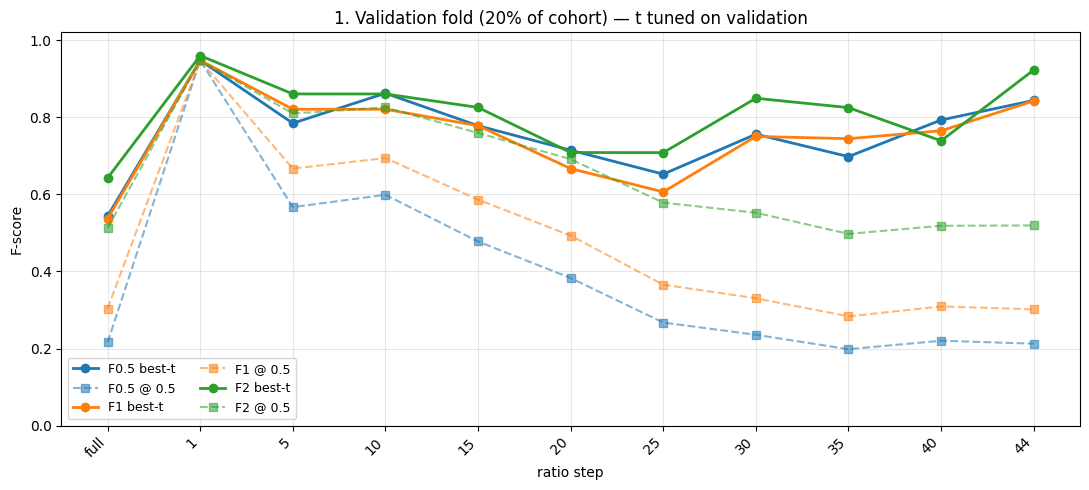

Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_curves_holdout_split_a.png


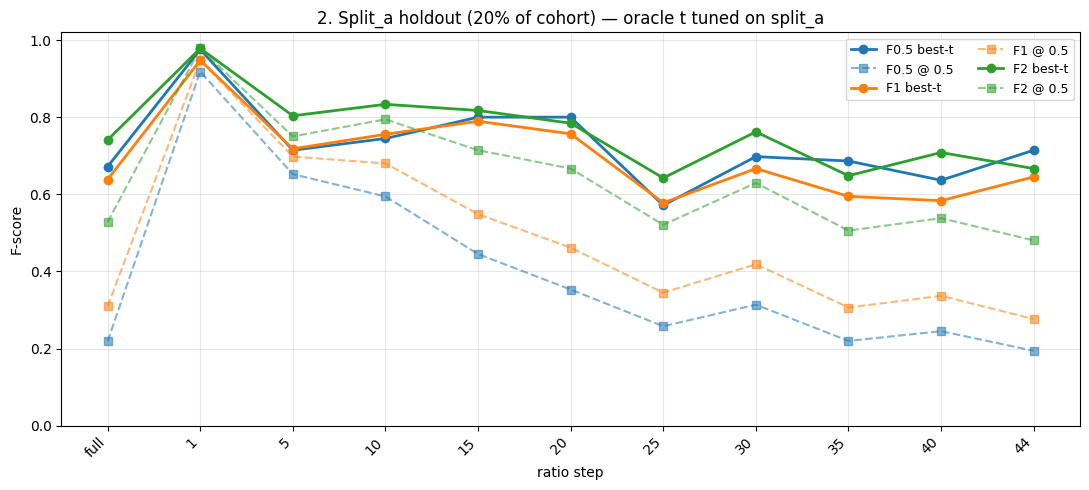

Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_curves_split_b_val.png


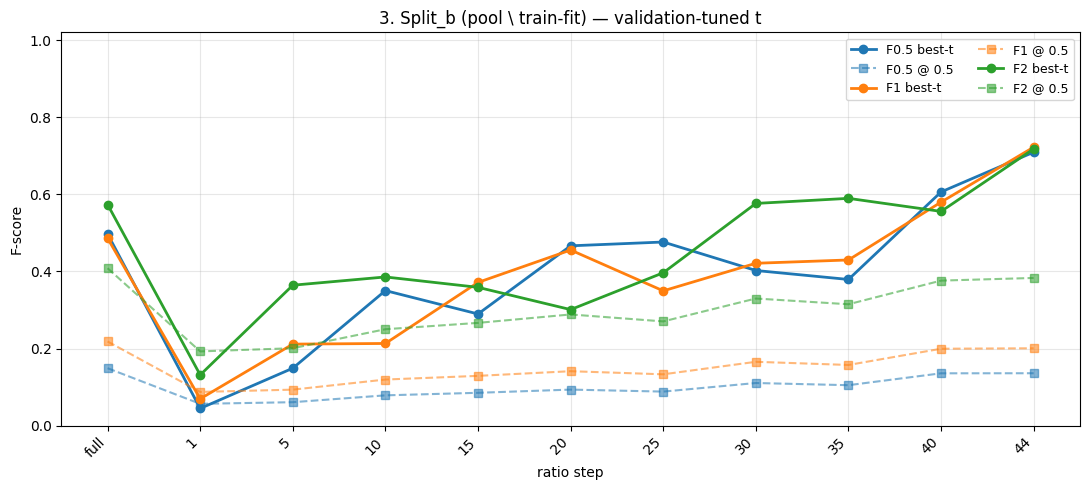

Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_curves_split_b_holdout.png


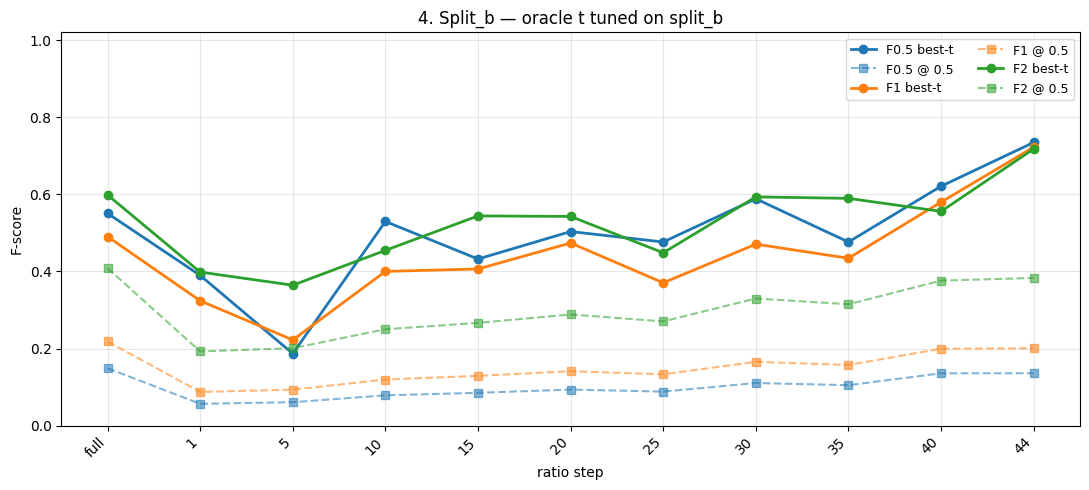

In [7]:
import matplotlib.pyplot as plt

try:
    _ = len(sweep_df)
except NameError:
    sweep_df = pd.read_csv(os.path.join(OUTPUT_DIR, "fp_followup_ratio_sweep.csv"))

_curve_df = sweep_df.sort_values("ratio_requested").reset_index(drop=True)
_x = np.arange(len(_curve_df))
_xlabels = [
    "full" if k == "full_pool" else str(int(r))
    for k, r in zip(_curve_df["step_kind"], _curve_df["ratio_requested"])
]

# --- F-score panels (solid = best-t, dashed = t 0.5) ---
_F_SCORE_SPECS = [
    (
        [
            ("F0.5", "val_f05_at_t_val", "val_f05_at_t05", "C0"),
            ("F1", "val_f1_at_t_val_f1", "val_f1_at_t05", "C1"),
            ("F2", "val_f2_at_t_val_f2", "val_f2_at_t05", "C2"),
        ],
        "F-scores | Validation (t tuned on val)",
        "fp_followup_curves_validation.png",
    ),
    (
        [
            ("F0.5", "hold_f05_at_t_hold", "hold_f05_at_t05", "C0"),
            ("F1", "hold_f1_at_t_hold_f1", "hold_f1_at_t05", "C1"),
            ("F2", "hold_f2_at_t_hold_f2", "hold_f2_at_t05", "C2"),
        ],
        "F-scores | Split_a holdout (oracle t on holdout)",
        "fp_followup_curves_holdout_split_a.png",
    ),
    (
        [
            ("F0.5", "b_tval_f05", "b_t05_f05", "C0"),
            ("F1", "b_tval_f1_f1", "b_t05_f1", "C1"),
            ("F2", "b_tval_f2_f2", "b_t05_f2", "C2"),
        ],
        "F-scores | Split_b (val-tuned t)",
        "fp_followup_curves_split_b_val.png",
    ),
    (
        [
            ("F0.5", "b_hold_f05_at_oracle", "b_hold_f05_at_t05", "C0"),
            ("F1", "b_hold_f1_at_oracle", "b_hold_f1_at_t05", "C1"),
            ("F2", "b_hold_f2_at_oracle", "b_hold_f2_at_t05", "C2"),
        ],
        "F-scores | Split_b (oracle t on split_b)",
        "fp_followup_curves_split_b_holdout.png",
    ),
]

# --- FP / FN panels: (label, fp_col, fn_col, color) ---
_ERROR_SPECS = [
    (
        [
            ("t=0.5", "val_t05_fp", "val_t05_fn", "0.45"),
            ("F0.5", "val_tval_fp", "val_tval_fn", "C0"),
            ("F1", "val_tval_f1_fp", "val_tval_f1_fn", "C1"),
            ("F2", "val_tval_f2_fp", "val_tval_f2_fn", "C2"),
        ],
        "FP & FN | Validation",
        "fp_followup_errors_validation.png",
    ),
    (
        [
            ("t=0.5", "a_t05_cm01", "a_t05_cm10", "0.45"),
            ("F0.5*", "a_thold_cm01", "a_thold_cm10", "C0"),
            ("F1*", "a_thold_f1_cm01", "a_thold_f1_cm10", "C1"),
            ("F2*", "a_thold_f2_cm01", "a_thold_f2_cm10", "C2"),
        ],
        "FP & FN | Split_a holdout (oracle t)",
        "fp_followup_errors_holdout_split_a.png",
    ),
    (
        [
            ("t=0.5", "b_t05_cm01", "b_t05_cm10", "0.45"),
            ("F0.5", "b_tval_cm01", "b_tval_cm10", "C0"),
            ("F1", "b_tval_f1_cm01", "b_tval_f1_cm10", "C1"),
            ("F2", "b_tval_f2_cm01", "b_tval_f2_cm10", "C2"),
        ],
        "FP & FN | Split_b (val-tuned t)",
        "fp_followup_errors_split_b_val.png",
    ),
    (
        [
            ("t=0.5", "b_t05_cm01", "b_t05_cm10", "0.45"),
            ("F0.5*", "b_thold_b_cm01", "b_thold_b_cm10", "C0"),
            ("F1*", "b_thold_b_f1_cm01", "b_thold_b_f1_cm10", "C1"),
            ("F2*", "b_thold_b_f2_cm01", "b_thold_b_f2_cm10", "C2"),
        ],
        "FP & FN | Split_b (oracle t)",
        "fp_followup_errors_split_b_holdout.png",
    ),
]

# --- AUC panels ---
_AUC_SPECS = [
    ("val_roc_auc", "val_pr_auc", "ROC & PR-AUC | Validation", "fp_followup_auc_validation.png"),
    ("hold_a_roc_auc", "hold_a_pr_auc", "ROC & PR-AUC | Split_a holdout", "fp_followup_auc_holdout_split_a.png"),
    ("split_b_roc_auc", "split_b_pr_auc", "ROC & PR-AUC | Split_b", "fp_followup_auc_split_b.png"),
]


def _save_show(fig, save_name):
    out = os.path.join(OUTPUT_DIR, save_name)
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print("Saved:", out)
    plt.show()


def _style_ratio_axis(ax, ylabel, title):
    ax.set_xticks(_x)
    ax.set_xticklabels(_xlabels, rotation=45, ha="right")
    ax.set_xlabel("ratio step")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)


def _plot_f_curves(series, title, save_name):
    fig, ax = plt.subplots(figsize=(11, 5))
    for name, col_best, col_05, color in series:
        if col_best not in _curve_df.columns:
            raise KeyError(f"Missing {col_best!r} — re-run §3 before §5")
        ax.plot(_x, _curve_df[col_best], "o-", color=color, linewidth=2, label=f"{name} best-t")
        ax.plot(
            _x, _curve_df[col_05], "s--", color=color, alpha=0.55, linewidth=1.5, label=f"{name} @ 0.5"
        )
    ax.set_ylim(0, 1.02)
    _style_ratio_axis(ax, "F-score", title)
    fig.tight_layout()
    _save_show(fig, save_name)


def _plot_fp_fn(series, title, save_name):
    fig, ax = plt.subplots(figsize=(11, 5))
    for label, col_fp, col_fn, color in series:
        for col in (col_fp, col_fn):
            if col not in _curve_df.columns:
                raise KeyError(f"Missing {col!r} — re-run §3 before §5")
        ax.plot(_x, _curve_df[col_fp], "o-", color=color, linewidth=2, label=f"{label} FP")
        ax.plot(
            _x, _curve_df[col_fn], "s--", color=color, alpha=0.7, linewidth=1.5, label=f"{label} FN"
        )
    _style_ratio_axis(ax, "count", title)
    fig.tight_layout()
    _save_show(fig, save_name)


def _plot_auc(roc_col, pr_col, title, save_name):
    if roc_col not in _curve_df.columns:
        raise KeyError(f"Missing {roc_col!r} — re-run §3 before §5")
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(_x, _curve_df[roc_col], "o-", color="C0", linewidth=2, label="ROC-AUC")
    ax.plot(_x, _curve_df[pr_col], "s-", color="C1", linewidth=2, label="PR-AUC")
    ax.set_ylim(0, 1.02)
    _style_ratio_axis(ax, "AUC", title)
    fig.tight_layout()
    _save_show(fig, save_name)


print("--- F-score curves ---")
for spec, title, fname in _F_SCORE_SPECS:
    _plot_f_curves(spec, title, fname)

print("--- FP / FN curves ---")
for spec, title, fname in _ERROR_SPECS:
    _plot_fp_fn(spec, title, fname)

print("--- AUC curves ---")
for roc_c, pr_c, title, fname in _AUC_SPECS:
    _plot_auc(roc_c, pr_c, title, fname)


## 5. Saved artifact paths


In [8]:
print(
    "Artifacts written to:",
    OUTPUT_DIR,
    "\n",
    " - fp_followup_ratio_sweep.csv",
)


Artifacts written to: /kaggle/working/vlst_fp_followup_output 
  - fp_followup_ratio_sweep.csv
